In [1]:

import math, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.nn.functional as F

np.random.seed(7)
random.seed(7)
torch.manual_seed(7)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device =", device)


device = cuda


In [2]:

# =========================
# Settings
# =========================
settings = {
    # data
    "D": 5,
    "target_edges": 5,
    "noise": 0.50,
    "n_train_per_comp": 500,
    "n_test_per_comp": 200,

    # mixture-particle teacher
    "M_particles": 12,
    "C_mix": 3,
    "particle_warmup": 500,
    "main_iters": 1500,
    "graph_warmup": 10,
    "move_every": 5,
    "graph_move_trials": 18,
    "edge_penalty": 0.03,
    "ridge": 1e-3,
    "min_pi_keep": 0.08,
    "top_particles_for_fm": 12,

    # simulator batch during one-stage alternating training
    "sim_per_component_per_iter": 12,

    # conditional coupled FM
    "fm_hidden": 128,
    "fm_batch": 256,
    "fm_updates_per_iter": 1,
    "lr_fm": 1e-3,
    "h0_scale": 1.0,
    "lambda_H": 1.0,  # fixed to 1 after loss normalization

    # generation/evaluation
    "gen_h_steps": 50,
    "gen_temp": 0.7,
    "n_graph_samples_panel": 3,
    "n_param_samples": 100,

    # exploration
    "graph_accept_temp": 0.01,
    "h_jitter_for_fm": 0.05,
    
}
settings


{'D': 5,
 'target_edges': 5,
 'noise': 0.5,
 'n_train_per_comp': 500,
 'n_test_per_comp': 200,
 'M_particles': 12,
 'C_mix': 3,
 'particle_warmup': 500,
 'main_iters': 1500,
 'graph_warmup': 10,
 'move_every': 5,
 'graph_move_trials': 18,
 'edge_penalty': 0.03,
 'ridge': 0.001,
 'min_pi_keep': 0.08,
 'top_particles_for_fm': 12,
 'sim_per_component_per_iter': 12,
 'fm_hidden': 128,
 'fm_batch': 256,
 'fm_updates_per_iter': 1,
 'lr_fm': 0.001,
 'h0_scale': 1.0,
 'lambda_H': 1.0,
 'gen_h_steps': 50,
 'gen_temp': 0.7,
 'n_graph_samples_panel': 3,
 'n_param_samples': 100,
 'graph_accept_temp': 0.01,
 'h_jitter_for_fm': 0.05}

In [3]:

# =========================
# Graph utilities
# =========================
D = settings["D"]
EDGE_LIST = [(i, j) for i in range(D) for j in range(D) if i != j]
E = len(EDGE_LIST)
EDGE_INDEX = {e: k for k, e in enumerate(EDGE_LIST)}

def graph_to_vec(G):
    return np.array([G[i, j] for (i, j) in EDGE_LIST], dtype=np.float32)

def vec_to_graph(g):
    G = np.zeros((D, D), dtype=int)
    for k, (i, j) in enumerate(EDGE_LIST):
        G[i, j] = int(g[k])
    return G

def edgevec_to_matrix_np(h):
    H = np.zeros((D, D), dtype=np.float32)
    for k, (i, j) in enumerate(EDGE_LIST):
        H[i, j] = float(h[k])
    return H

def is_dag(G):
    G = np.asarray(G).astype(int)
    indeg = G.sum(axis=0).astype(int).tolist()
    q = [j for j in range(D) if indeg[j] == 0]
    seen = 0
    while q:
        j = q.pop(0)
        seen += 1
        for k in np.where(G[j] == 1)[0]:
            indeg[k] -= 1
            if indeg[k] == 0:
                q.append(int(k))
    return seen == D

def topo_order(G):
    G = np.asarray(G).astype(int)
    indeg = G.sum(axis=0).astype(int).tolist()
    q = [j for j in range(D) if indeg[j] == 0]
    order = []
    while q:
        j = q.pop(0)
        order.append(int(j))
        for k in np.where(G[j] == 1)[0]:
            indeg[k] -= 1
            if indeg[k] == 0:
                q.append(int(k))
    if len(order) != D:
        raise ValueError("graph is not DAG")
    return order

def graph_dist(Ga, Gb):
    return int(np.abs(np.asarray(Ga).astype(int) - np.asarray(Gb).astype(int)).sum())

def random_dag(target_edges=5):
    while True:
        perm = np.random.permutation(D)
        possible = []
        for a in range(D):
            for b in range(a + 1, D):
                possible.append((perm[a], perm[b]))
        chosen = random.sample(possible, target_edges)
        G = np.zeros((D, D), dtype=int)
        for i, j in chosen:
            G[i, j] = 1
        if is_dag(G):
            return graph_to_vec(G)

def valid_add_edges(g_vec):
    G = vec_to_graph(g_vec.astype(int))
    valid = np.zeros(E, dtype=bool)
    for k, (i, j) in enumerate(EDGE_LIST):
        if G[i, j] == 1:
            continue
        G2 = G.copy()
        G2[i, j] = 1
        if is_dag(G2):
            valid[k] = True
    return valid


In [4]:

# =========================
# Ground truth
# =========================
G_TRUE_1 = np.zeros((D, D), dtype=int)
for i, j in [(0, 1), (0, 2), (1, 3), (2, 3), (3, 4)]:
    G_TRUE_1[i, j] = 1

G_TRUE_2 = np.zeros((D, D), dtype=int)
for i, j in [(4, 0), (4, 2), (0, 1), (2, 3), (1, 3)]:
    G_TRUE_2[i, j] = 1

H_TRUE_1 = np.zeros((D, D), dtype=np.float32)
H_TRUE_1[0, 1] = 1.0
H_TRUE_1[0, 2] = -1.2
H_TRUE_1[1, 3] = 1.1
H_TRUE_1[2, 3] = 0.8
H_TRUE_1[3, 4] = 1.0

H_TRUE_2 = np.zeros((D, D), dtype=np.float32)
H_TRUE_2[4, 0] = 1.0
H_TRUE_2[4, 2] = -1.1
H_TRUE_2[0, 1] = 0.9
H_TRUE_2[2, 3] = 1.0
H_TRUE_2[1, 3] = -0.8

assert is_dag(G_TRUE_1) and is_dag(G_TRUE_2)
print("dist(G1, G2) =", graph_dist(G_TRUE_1, G_TRUE_2))


dist(G1, G2) = 4


In [5]:

# =========================
# SEM simulator and pseudo-likelihood
# =========================
def simulate_sem_np(G, H, n, noise=0.50):
    G = np.asarray(G).astype(int)
    H = np.asarray(H).astype(np.float32) * G
    X = np.zeros((n, D), dtype=np.float32)
    eps = noise * np.random.randn(n, D).astype(np.float32)
    for j in topo_order(G):
        pa = np.where(G[:, j] == 1)[0]
        if len(pa) == 0:
            X[:, j] = eps[:, j]
        else:
            X[:, j] = np.tanh(X[:, pa]) @ H[pa, j] + eps[:, j]
    return X

def fit_H_given_G_np(X, g_vec, ridge=1e-3, weights=None):
    G = vec_to_graph(g_vec.astype(int))
    H = np.zeros((D, D), dtype=np.float32)
    if weights is None:
        weights = np.ones(len(X), dtype=np.float32)
    weights = weights.astype(np.float32)
    for j in range(D):
        pa = np.where(G[:, j] == 1)[0]
        if len(pa) == 0:
            continue
        Xp = np.tanh(X[:, pa]).astype(np.float32)
        y = X[:, j].astype(np.float32)
        sw = np.sqrt(weights + 1e-8)[:, None]
        A = Xp * sw
        b = y * sw[:, 0]
        M = A.T @ A + ridge * np.eye(len(pa), dtype=np.float32)
        rhs = A.T @ b
        coef = np.linalg.solve(M, rhs)
        H[pa, j] = coef.astype(np.float32)
    h_vec = np.array([H[i, j] for (i, j) in EDGE_LIST], dtype=np.float32)
    return graph_to_vec(G), h_vec

def component_loglik(X, g_vec, h_vec, noise=0.50):
    G = vec_to_graph(g_vec.astype(int))
    H = edgevec_to_matrix_np(h_vec * g_vec)
    pred = np.zeros_like(X, dtype=np.float32)
    for j in range(D):
        pa = np.where(G[:, j] == 1)[0]
        if len(pa) > 0:
            pred[:, j] = np.tanh(X[:, pa]) @ H[pa, j]
    rss = ((X - pred) ** 2).sum(axis=1)
    return -0.5 * rss / (noise ** 2)


In [6]:

# =========================
# Training and testing data
# =========================
X_train_1 = simulate_sem_np(G_TRUE_1, H_TRUE_1, settings["n_train_per_comp"], settings["noise"])
X_train_2 = simulate_sem_np(G_TRUE_2, H_TRUE_2, settings["n_train_per_comp"], settings["noise"])
X_test_1  = simulate_sem_np(G_TRUE_1, H_TRUE_1, settings["n_test_per_comp"], settings["noise"])
X_test_2  = simulate_sem_np(G_TRUE_2, H_TRUE_2, settings["n_test_per_comp"], settings["noise"])

X_train = np.vstack([X_train_1, X_train_2]).astype(np.float32)
z_train = np.array([0] * len(X_train_1) + [1] * len(X_train_2), dtype=int)
X_test  = np.vstack([X_test_1, X_test_2]).astype(np.float32)
z_test  = np.array([0] * len(X_test_1) + [1] * len(X_test_2), dtype=int)

X_mean = X_train.mean(axis=0, keepdims=True)
X_sd = X_train.std(axis=0, keepdims=True) + 1e-6
X_train_std = (X_train - X_mean) / X_sd
X_test_std = (X_test - X_mean) / X_sd

pca = PCA(n_components=2).fit(X_train_std)
P_train = pca.transform(X_train_std)
P_test = pca.transform(X_test_std)


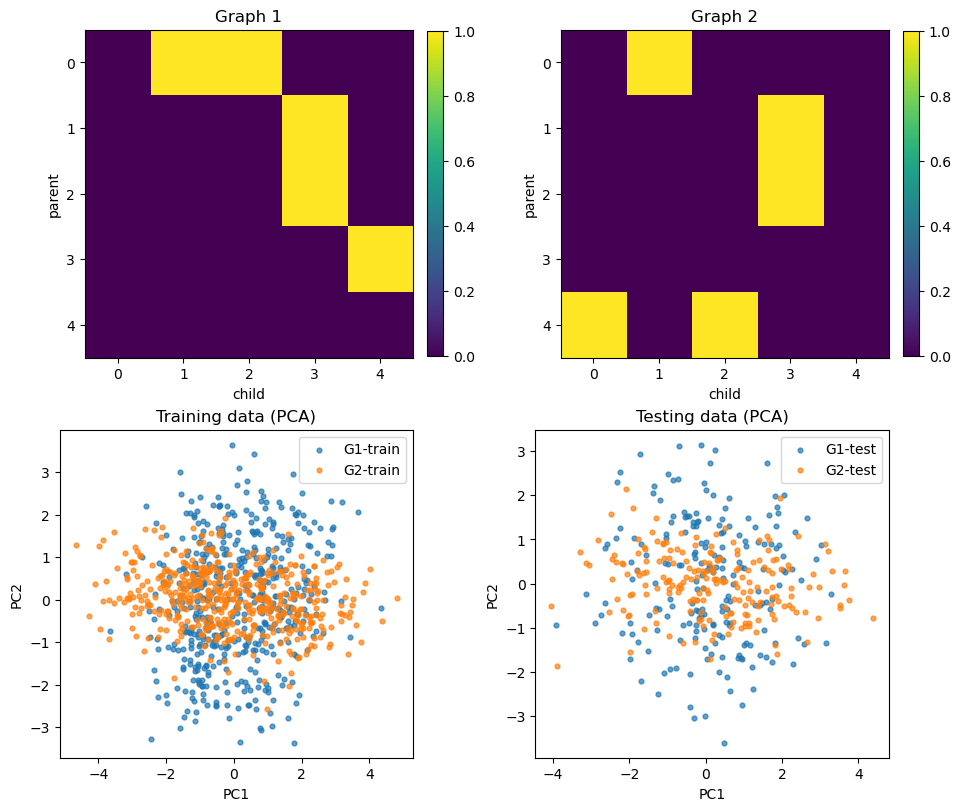

In [7]:
# =========================
# Before-training figures: 2-by-2
# =========================
def draw_graph_heatmap(ax, G, title):
    im = ax.imshow(G, vmin=0, vmax=1, cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("child")
    ax.set_ylabel("parent")
    ax.set_xticks(range(D))
    ax.set_yticks(range(D))
    return im

fig, axes = plt.subplots(2, 2, figsize=(9.5, 8.0), constrained_layout=True)

# Top row: truth graphs
im1 = draw_graph_heatmap(axes[0, 0], G_TRUE_1, "Graph 1")
im2 = draw_graph_heatmap(axes[0, 1], G_TRUE_2, "Graph 2")

fig.colorbar(im1, ax=axes[0, 0], fraction=0.046, pad=0.04)
fig.colorbar(im2, ax=axes[0, 1], fraction=0.046, pad=0.04)

# Bottom-left: training data
for lab, name in [(0, "G1-train"), (1, "G2-train")]:
    idx = z_train == lab
    axes[1, 0].scatter(P_train[idx, 0], P_train[idx, 1], s=12, alpha=0.7, label=name)

axes[1, 0].set_title("Training data (PCA)")
axes[1, 0].set_xlabel("PC1")
axes[1, 0].set_ylabel("PC2")
axes[1, 0].legend()

# Bottom-right: testing data
for lab, name in [(0, "G1-test"), (1, "G2-test")]:
    idx = z_test == lab
    axes[1, 1].scatter(P_test[idx, 0], P_test[idx, 1], s=12, alpha=0.7, label=name)

axes[1, 1].set_title("Testing data (PCA)")
axes[1, 1].set_xlabel("PC1")
axes[1, 1].set_ylabel("PC2")
axes[1, 1].legend()

plt.show()

In [8]:

# =========================
# Explicit-mixture particles
# =========================
def logsumexp_np(A, axis=1):
    m = np.max(A, axis=axis, keepdims=True)
    return np.squeeze(m + np.log(np.sum(np.exp(A - m), axis=axis, keepdims=True) + 1e-12), axis=axis)

def score_particle(particle, X):
    pi, Gs, Hs = particle["pi"], particle["Gs"], particle["Hs"]
    comp = []
    for c in range(len(pi)):
        ll = component_loglik(X, Gs[c], Hs[c], settings["noise"])
        comp.append(np.log(pi[c] + 1e-12) + ll)
    comp = np.column_stack(comp)
    mix = logsumexp_np(comp, axis=1).mean()
    pen_g = settings["edge_penalty"] * np.sum(pi * np.array([Gs[c].sum() for c in range(len(pi))]))
    pen_h = 1e-4 * np.sum(pi * np.array([(Hs[c] ** 2).sum() for c in range(len(pi))]))
    return float(mix - pen_g - pen_h)

def e_step(particle, X):
    C = len(particle["pi"])
    comp = []
    for c in range(C):
        ll = component_loglik(X, particle["Gs"][c], particle["Hs"][c], settings["noise"])
        comp.append(np.log(particle["pi"][c] + 1e-12) + ll)
    comp = np.column_stack(comp)
    lse = logsumexp_np(comp, axis=1)
    R = np.exp(comp - lse[:, None])
    return R, lse.mean()

def init_particle():
    C = settings["C_mix"]
    Gs, Hs = [], []
    for _ in range(C):
        g = random_dag(settings["target_edges"])
        _, h = fit_H_given_G_np(X_train, g, ridge=settings["ridge"])
        h = h + 0.25 * np.random.randn(E).astype(np.float32) * g
        Gs.append(g.astype(np.float32))
        Hs.append((h * g).astype(np.float32))
    pi = np.random.dirichlet(np.ones(C)).astype(np.float32)
    particle = {"pi": pi, "Gs": np.stack(Gs), "Hs": np.stack(Hs)}
    particle["score"] = score_particle(particle, X_train)
    return particle

def propose_graphs(g_vec, n_trials=16):
    props = []
    present = [k for k, v in enumerate(g_vec.astype(int)) if v == 1]
    absent = [k for k, v in enumerate(g_vec.astype(int)) if v == 0]
    for _ in range(n_trials):
        move = random.choice(["add", "remove", "swap"])
        g2 = g_vec.copy().astype(int)
        if move == "remove" and len(present) > 0:
            g2[random.choice(present)] = 0
        elif move == "add" and len(absent) > 0:
            g2[random.choice(absent)] = 1
            if not is_dag(vec_to_graph(g2)):
                continue
        else:
            if len(present) == 0 or len(absent) == 0:
                continue
            g2[random.choice(present)] = 0
            g2[random.choice(absent)] = 1
            if not is_dag(vec_to_graph(g2)):
                continue
        props.append(g2.astype(np.float32))

    uniq, seen = [], set()
    for g in props:
        key = tuple(g.astype(int).tolist())
        if key not in seen:
            seen.add(key)
            uniq.append(g)
    return uniq


def try_graph_move(particle, c, R):
    """
    Less-greedy graph movement.

    Instead of only keeping the best proposed graph, we walk through proposals
    and accept by annealed score improvement:

        accept if ΔQ > 0,
        or with probability exp(ΔQ / T) if ΔQ < 0.

    This encourages exploration over G while still favoring better particles.
    """
    T = max(settings.get("graph_accept_temp", 0.03), 1e-8)
    w = R[:, c]

    for g_prop in propose_graphs(particle["Gs"][c], settings["graph_move_trials"]):
        _, h_prop = fit_H_given_G_np(
            X_train,
            g_prop,
            ridge=settings["ridge"],
            weights=w,
        )

        cand = {
            "pi": particle["pi"].copy(),
            "Gs": particle["Gs"].copy(),
            "Hs": particle["Hs"].copy(),
        }

        cand["Gs"][c] = g_prop.copy()
        cand["Hs"][c] = (h_prop * g_prop).copy()
        cand["score"] = score_particle(cand, X_train)

        delta = cand["score"] - particle["score"]

        if delta >= 0:
            particle = cand
        else:
            if np.log(np.random.rand() + 1e-12) < delta / T:
                particle = cand

    return particle



# def try_graph_move(particle, c, R):
#     best_score = particle["score"]
#     best_g = particle["Gs"][c].copy()
#     best_h = particle["Hs"][c].copy()
#     w = R[:, c]

#     for g_prop in propose_graphs(particle["Gs"][c], settings["graph_move_trials"]):
#         _, h_prop = fit_H_given_G_np(X_train, g_prop, ridge=settings["ridge"], weights=w)
#         cand = {
#             "pi": particle["pi"].copy(),
#             "Gs": particle["Gs"].copy(),
#             "Hs": particle["Hs"].copy(),
#         }
#         cand["Gs"][c] = g_prop.copy()
#         cand["Hs"][c] = (h_prop * g_prop).copy()
#         sc = score_particle(cand, X_train)
#         if sc > best_score:
#             best_score = sc
#             best_g = g_prop.copy()
#             best_h = (h_prop * g_prop).copy()

#     particle["Gs"][c] = best_g
#     particle["Hs"][c] = best_h
#     particle["score"] = best_score
#     return particle

def update_particles_once(particles, iteration):
    for m, p in enumerate(particles):
        R, _ = e_step(p, X_train)

        # EM-style pi update
        p["pi"] = R.mean(axis=0).astype(np.float32)
        p["pi"] = p["pi"] / (p["pi"].sum() + 1e-12)

        # EM-style H update
        for c in range(settings["C_mix"]):
            _, h = fit_H_given_G_np(X_train, p["Gs"][c], ridge=settings["ridge"], weights=R[:, c])
            p["Hs"][c] = (h * p["Gs"][c]).astype(np.float32)

        p["score"] = score_particle(p, X_train)

        # less-frequent greedy DAG movement
        if iteration >= settings["graph_warmup"] and iteration % settings["move_every"] == 0:
            R, _ = e_step(p, X_train)
            for c in range(settings["C_mix"]):
                p = try_graph_move(p, c, R)

        particles[m] = p
    return particles


In [9]:

# =========================
# Conditional coupled FM
# =========================
def sample_partial_graph_batch(g1, t):
    bern = torch.rand_like(g1)
    return ((bern < t) & (g1 > 0.5)).float()

def valid_add_mask_single(g_vec):
    g_np = g_vec.detach().cpu().numpy().astype(int)
    return torch.tensor(valid_add_edges(g_np), dtype=torch.float32, device=g_vec.device)

class CoupledFM(nn.Module):
    def __init__(self, x_dim=D, edge_dim=E, hidden=128):
        super().__init__()
        in_dim = x_dim + edge_dim + edge_dim + 1
        self.trunk = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.graph_head = nn.Linear(hidden, edge_dim)
        self.h_head = nn.Linear(hidden, edge_dim)

    def forward(self, x, g_t, h_t, t):
        z = torch.cat([x, g_t, h_t, t], dim=1)
        u = self.trunk(z)
        return self.graph_head(u), self.h_head(u)

fm = CoupledFM(hidden=settings["fm_hidden"]).to(device)
opt_fm = torch.optim.Adam(fm.parameters(), lr=settings["lr_fm"])

def make_teacher_bank(particles):
    scores = np.array([p["score"] for p in particles])
    ranked = np.argsort(scores)[::-1][:settings["top_particles_for_fm"]]
    bank = []
    for m in ranked:
        p = particles[m]
        for c in range(settings["C_mix"]):
            if p["pi"][c] < settings["min_pi_keep"]:
                continue
            bank.append({
                "particle_idx": int(m),
                "comp_idx": int(c),
                "pi": float(p["pi"][c]),
                "score": float(p["score"]),
                "g": p["Gs"][c].copy(),
                "h": p["Hs"][c].copy(),
                "dist_G1": graph_dist(vec_to_graph(p["Gs"][c]), G_TRUE_1),
                "dist_G2": graph_dist(vec_to_graph(p["Gs"][c]), G_TRUE_2),
            })
    if len(bank) == 0:
        # fallback: use all components from the best particle
        m = int(np.argmax(scores))
        p = particles[m]
        for c in range(settings["C_mix"]):
            bank.append({
                "particle_idx": int(m),
                "comp_idx": int(c),
                "pi": float(p["pi"][c]),
                "score": float(p["score"]),
                "g": p["Gs"][c].copy(),
                "h": p["Hs"][c].copy(),
                "dist_G1": graph_dist(vec_to_graph(p["Gs"][c]), G_TRUE_1),
                "dist_G2": graph_dist(vec_to_graph(p["Gs"][c]), G_TRUE_2),
            })
    return bank

def simulate_fm_batch_from_bank(bank):
    """
    Generate unweighted FM training triples from current teacher components.

    Add small H-jitter here, not inside the particle state.
    This gives FM local parameter-space support without corrupting EM updates.
    """
    Xb, Gb, Hb = [], [], []

    h_jitter = settings.get("h_jitter_for_fm", 0.0)

    for b in bank:
        g = b["g"].astype(np.float32)
        h = b["h"].astype(np.float32) * g

        if h_jitter > 0:
            h_use = h + h_jitter * np.random.randn(E).astype(np.float32) * g
            h_use = h_use * g
        else:
            h_use = h

        Gm = vec_to_graph(g.astype(int))
        Hm = edgevec_to_matrix_np(h_use)

        Xsim = simulate_sem_np(
            Gm,
            Hm,
            settings["sim_per_component_per_iter"],
            settings["noise"],
        )

        for x in Xsim:
            Xb.append(x.astype(np.float32))
            Gb.append(g.astype(np.float32))
            Hb.append(h_use.astype(np.float32))

    Xb = np.stack(Xb).astype(np.float32)
    Gb = np.stack(Gb).astype(np.float32)
    Hb = np.stack(Hb).astype(np.float32)

    Xb_std = ((Xb - X_mean) / X_sd).astype(np.float32)

    return Xb_std, Gb, Hb


# def simulate_fm_batch_from_bank(bank):
#     Xb, Gb, Hb = [], [], []
#     for b in bank:
#         Gm = vec_to_graph(b["g"].astype(int))
#         Hm = edgevec_to_matrix_np(b["h"])
#         Xsim = simulate_sem_np(Gm, Hm, settings["sim_per_component_per_iter"], settings["noise"])
#         for x in Xsim:
#             Xb.append(x.astype(np.float32))
#             Gb.append(b["g"].astype(np.float32))
#             Hb.append((b["h"] * b["g"]).astype(np.float32))
#     Xb = np.stack(Xb).astype(np.float32)
#     Gb = np.stack(Gb).astype(np.float32)
#     Hb = np.stack(Hb).astype(np.float32)
#     Xb_std = ((Xb - X_mean) / X_sd).astype(np.float32)
#     return Xb_std, Gb, Hb

def fm_update_from_batch(Xb_std, Gb_np, Hb_np):
    X_t = torch.tensor(Xb_std, dtype=torch.float32, device=device)
    G_targ = torch.tensor(Gb_np, dtype=torch.float32, device=device)
    H_targ = torch.tensor(Hb_np, dtype=torch.float32, device=device)

    losses = []
    for _ in range(settings["fm_updates_per_iter"]):
        B = min(settings["fm_batch"], len(X_t))
        idx = torch.randint(0, len(X_t), (B,), device=device)

        x1 = X_t[idx]
        g1 = G_targ[idx]
        h1 = H_targ[idx]

        t = torch.rand(B, 1, device=device)
        h0 = settings["h0_scale"] * torch.randn_like(h1)
        ht = (1 - t) * h0 + t * h1
        vt = h1 - h0
        gt = sample_partial_graph_batch(g1, t)

        logits_g, vel_h = fm(x1, gt, ht, t)

        # DeFoG-like masked graph loss: only currently absent valid actions.
        graph_loss_sum = 0.0
        graph_den = 0
        for b in range(B):
            valid = valid_add_mask_single(gt[b])
            mask = ((gt[b] < 0.5) & (valid > 0.5))
            if mask.sum() > 0:
                graph_loss_sum = graph_loss_sum + F.binary_cross_entropy_with_logits(
                    logits_g[b][mask], g1[b][mask], reduction="sum"
                )
                graph_den += int(mask.sum().item())
        loss_g = graph_loss_sum / max(graph_den, 1)

        # continuous FM loss for H, masked to target true edges.
        hmask = (g1 > 0.5).float()
        loss_h = ((vel_h - vt) ** 2 * hmask).sum() / hmask.sum().clamp(min=1.0)

        # lambda_H = 1 after normalization; no FM sample weights.
        loss = loss_g + settings["lambda_H"] * loss_h

        opt_fm.zero_grad()
        loss.backward()
        opt_fm.step()

        losses.append((float(loss.item()), float(loss_g.item()), float(loss_h.item())))

    return np.mean(losses, axis=0)


In [10]:

# =========================
# One-stage alternating training
# =========================
particles = [init_particle() for _ in range(settings["M_particles"])]

hist = []
fm_hist = []
bank_last = []

total_iters = settings["particle_warmup"] + settings["main_iters"]

for it in range(1, total_iters + 1):
    # Block A: particle movement.
    particles = update_particles_once(particles, it)

    scores = np.array([p["score"] for p in particles])
    best_idx = int(np.argmax(scores))
    best_p = particles[best_idx]
    d1 = [graph_dist(vec_to_graph(best_p["Gs"][c]), G_TRUE_1) for c in range(settings["C_mix"])]
    d2 = [graph_dist(vec_to_graph(best_p["Gs"][c]), G_TRUE_2) for c in range(settings["C_mix"])]

    # Blocks B/C: after warmup, simulate from current good components and update FM.
    if it > settings["particle_warmup"]:
        bank_last = make_teacher_bank(particles)
        Xb_std, Gb_np, Hb_np = simulate_fm_batch_from_bank(bank_last)
        loss, loss_g, loss_h = fm_update_from_batch(Xb_std, Gb_np, Hb_np)
        fm_hist.append({"iter": it, "loss": loss, "loss_g": loss_g, "loss_h": loss_h})
    else:
        loss, loss_g, loss_h = np.nan, np.nan, np.nan

    hist.append({
        "iter": it,
        "phase": "warmup" if it <= settings["particle_warmup"] else "alternating",
        "best_score": float(scores.max()),
        "mean_score": float(scores.mean()),
        "best_particle": best_idx,
        "best_min_d1": int(np.min(d1)),
        "best_min_d2": int(np.min(d2)),
        "fm_loss": float(loss) if not np.isnan(loss) else np.nan,
        "fm_loss_g": float(loss_g) if not np.isnan(loss_g) else np.nan,
        "fm_loss_h": float(loss_h) if not np.isnan(loss_h) else np.nan,
    })

    if it == 1 or it % 50 == 0 or it == settings["particle_warmup"]:
        print(
            f"{it:04d} | {hist[-1]['phase']} | "
            f"score best {scores.max():.4f} mean {scores.mean():.4f} | "
            f"best min-dist ({np.min(d1)}, {np.min(d2)}) | "
            f"FM {loss if not np.isnan(loss) else None}"
        )

hist = pd.DataFrame(hist)
fm_hist = pd.DataFrame(fm_hist)


0001 | warmup | score best -3.6482 mean -3.8364 | best min-dist (4, 4) | FM None
0050 | warmup | score best -3.0967 mean -3.2561 | best min-dist (1, 1) | FM None
0100 | warmup | score best -3.0814 mean -3.1753 | best min-dist (0, 1) | FM None
0150 | warmup | score best -3.0842 mean -3.1399 | best min-dist (1, 0) | FM None
0200 | warmup | score best -3.0655 mean -3.0999 | best min-dist (0, 0) | FM None
0250 | warmup | score best -3.0682 mean -3.1000 | best min-dist (0, 0) | FM None
0300 | warmup | score best -3.0682 mean -3.0896 | best min-dist (0, 0) | FM None
0350 | warmup | score best -3.0642 mean -3.0850 | best min-dist (0, 0) | FM None
0400 | warmup | score best -3.0642 mean -3.0802 | best min-dist (0, 0) | FM None
0450 | warmup | score best -3.0682 mean -3.0840 | best min-dist (0, 0) | FM None
0500 | warmup | score best -3.0662 mean -3.0871 | best min-dist (0, 0) | FM None
0550 | alternating | score best -3.0681 mean -3.0816 | best min-dist (0, 0) | FM 1.235945701599121
0600 | alt

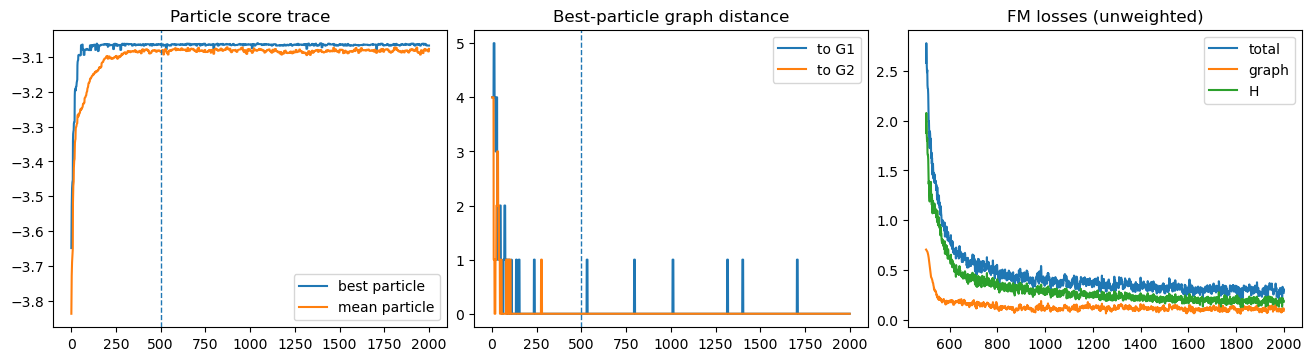

In [11]:

# Movement / training traces.
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5), constrained_layout=True)

axes[0].plot(hist["iter"], hist["best_score"], label="best particle")
axes[0].plot(hist["iter"], hist["mean_score"], label="mean particle")
axes[0].axvline(settings["particle_warmup"], linestyle="--", linewidth=1)
axes[0].set_title("Particle score trace")
axes[0].legend()

axes[1].plot(hist["iter"], hist["best_min_d1"], label="to G1")
axes[1].plot(hist["iter"], hist["best_min_d2"], label="to G2")
axes[1].axvline(settings["particle_warmup"], linestyle="--", linewidth=1)
axes[1].set_title("Best-particle graph distance")
axes[1].legend()

if len(fm_hist) > 0:
    axes[2].plot(fm_hist["iter"], fm_hist["loss"], label="total")
    axes[2].plot(fm_hist["iter"], fm_hist["loss_g"], label="graph")
    axes[2].plot(fm_hist["iter"], fm_hist["loss_h"], label="H")
axes[2].set_title("FM losses (unweighted)")
axes[2].legend()

plt.show()


In [12]:

# Final teacher-bank summary.
bank_final = make_teacher_bank(particles)
bank_df = pd.DataFrame([{k: v for k, v in b.items() if k not in ("g", "h")} for b in bank_final])
print("final teacher-bank components:", len(bank_final))
display(bank_df.sort_values(["particle_idx", "comp_idx"]))


final teacher-bank components: 24


,particle_idx,comp_idx,pi,score,dist_G1,dist_G2
2,0,1,0.499345,-3.068114,4,0
3,0,2,0.499295,-3.068114,0,4
8,1,1,0.499232,-3.068614,4,0
9,1,2,0.498506,-3.068614,0,4
4,2,0,0.499596,-3.068229,4,0
5,2,1,0.500404,-3.068229,0,4
12,3,0,0.498007,-3.081977,5,1
13,3,2,0.501993,-3.081977,0,4
18,4,0,0.500401,-3.083192,1,5
19,4,2,0.499599,-3.083192,4,0


In [13]:

# =========================
# FM posterior generation
# =========================
def sample_one_posterior(model, x_cond_std, target_edges=5, n_h_steps=18, temp=1.0):
    model.eval()
    with torch.no_grad():
        x = torch.tensor(x_cond_std[None, :], dtype=torch.float32, device=device)
        g = torch.zeros(1, E, dtype=torch.float32, device=device)
        h = settings["h0_scale"] * torch.randn(1, E, dtype=torch.float32, device=device)

        edge_schedule = set(np.linspace(0, n_h_steps - 1, target_edges, dtype=int).tolist())
        for s in range(n_h_steps):
            t = torch.tensor([[s / max(n_h_steps - 1, 1)]], dtype=torch.float32, device=device)
            logits_g, vel_h = model(x, g, h, t)
            h = h + vel_h / n_h_steps

            if s in edge_schedule:
                valid = valid_add_mask_single(g[0]) * (1.0 - g[0])
                if valid.sum() > 0:
                    valid_idx = torch.where(valid > 0)[0]
                    probs = torch.softmax(logits_g[0][valid > 0] / temp, dim=0)
                    chosen = valid_idx[torch.multinomial(probs, 1)]
                    g[0, chosen] = 1.0

        g_np = g[0].cpu().numpy().astype(np.float32)
        h_np = (h[0].cpu().numpy() * g_np).astype(np.float32)
        return g_np, h_np

def sample_many_posterior(model, X_std, n_per_x=1):
    Gs, Hs = [], []
    for x in X_std:
        for _ in range(n_per_x):
            g, h = sample_one_posterior(
                model, x,
                target_edges=settings["target_edges"],
                n_h_steps=settings["gen_h_steps"],
                temp=settings["gen_temp"]
            )
            Gs.append(g)
            Hs.append(h)
    return np.stack(Gs), np.stack(Hs)

def sample_H_given_fixed_graph(model, x_cond_std, g_target, n_samples=64, n_h_steps=18):
    model.eval()
    g1 = torch.tensor(g_target[None, :], dtype=torch.float32, device=device)
    x = torch.tensor(x_cond_std[None, :], dtype=torch.float32, device=device)
    Hs = []
    true_edges = np.where(g_target.astype(int) == 1)[0].tolist()

    with torch.no_grad():
        for _ in range(n_samples):
            h = settings["h0_scale"] * torch.randn(1, E, dtype=torch.float32, device=device)
            edge_order = true_edges.copy()
            random.shuffle(edge_order)

            for s in range(n_h_steps):
                t_val = s / max(n_h_steps - 1, 1)
                t = torch.tensor([[t_val]], dtype=torch.float32, device=device)

                # Deterministic partial target graph path for a fixed target graph.
                n_on = int(round(t_val * len(edge_order)))
                g_t_np = np.zeros(E, dtype=np.float32)
                if n_on > 0:
                    g_t_np[edge_order[:n_on]] = 1.0
                g_t = torch.tensor(g_t_np[None, :], dtype=torch.float32, device=device)

                _, vel_h = model(x, g_t, h, t)
                h = h + vel_h / n_h_steps

            Hs.append((h[0].cpu().numpy() * g_target).astype(np.float32))
    return np.stack(Hs)


In [14]:

# Generate posterior samples for the test set.
G_post, H_post = sample_many_posterior(fm, X_test_std, n_per_x=1)
G_post_adj = np.stack([vec_to_graph(g.astype(int)) for g in G_post])


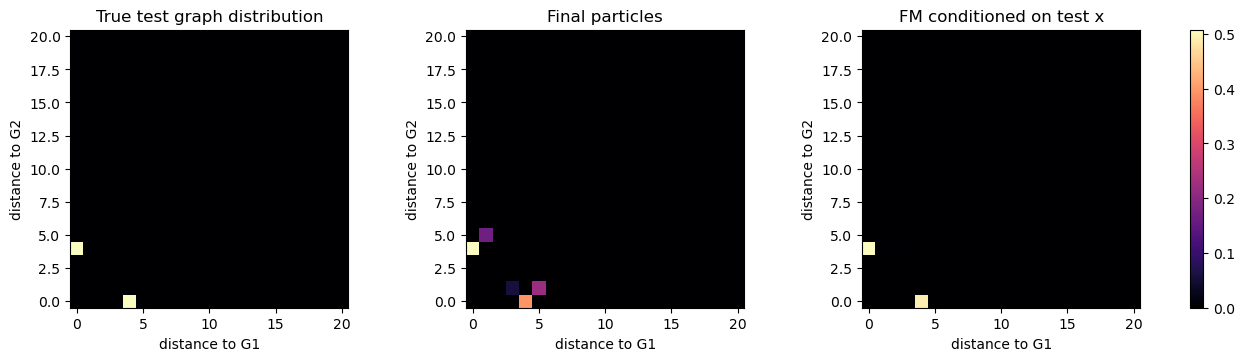

In [15]:

# =========================
# Result 3.1: graph distribution
# =========================
def graph_grid(A_samples, weights=None):
    if weights is None:
        weights = np.ones(len(A_samples), dtype=np.float32) / max(len(A_samples), 1)
    grid = np.zeros((E + 1, E + 1), dtype=np.float32)
    for A, w in zip(A_samples, weights):
        d1 = graph_dist(A, G_TRUE_1)
        d2 = graph_dist(A, G_TRUE_2)
        grid[d2, d1] += float(w)
    return grid

A_true = np.stack([G_TRUE_1] * np.sum(z_test == 0) + [G_TRUE_2] * np.sum(z_test == 1))
true_grid = graph_grid(A_true)

scores = np.array([p["score"] for p in particles])
ranked_idx = np.argsort(scores)[::-1][:settings["top_particles_for_fm"]]
particle_graphs, particle_weights = [], []
score_mass = np.exp(scores[ranked_idx] - scores[ranked_idx].max())
score_mass = score_mass / (score_mass.sum() + 1e-12)
for mass, m in zip(score_mass, ranked_idx):
    p = particles[m]
    for c in range(settings["C_mix"]):
        particle_graphs.append(vec_to_graph(p["Gs"][c].astype(int)))
        particle_weights.append(float(mass * p["pi"][c]))
particle_weights = np.array(particle_weights, dtype=np.float32)
particle_weights = particle_weights / (particle_weights.sum() + 1e-12)

particle_grid = graph_grid(np.stack(particle_graphs), particle_weights)
fm_grid = graph_grid(G_post_adj)

fig, axes = plt.subplots(1, 3, figsize=(12.8, 3.5), constrained_layout=True)
ims = []
for ax, grid, ttl in zip(
    axes,
    [true_grid, particle_grid, fm_grid],
    ["True test graph distribution", "Final particles", "FM conditioned on test x"],
):
    im = ax.imshow(grid, origin="lower", cmap="magma")
    ims.append(im)
    ax.set_title(ttl)
    ax.set_xlabel("distance to G1")
    ax.set_ylabel("distance to G2")
fig.colorbar(ims[-1], ax=axes.ravel().tolist(), fraction=0.03, pad=0.04)
plt.show()


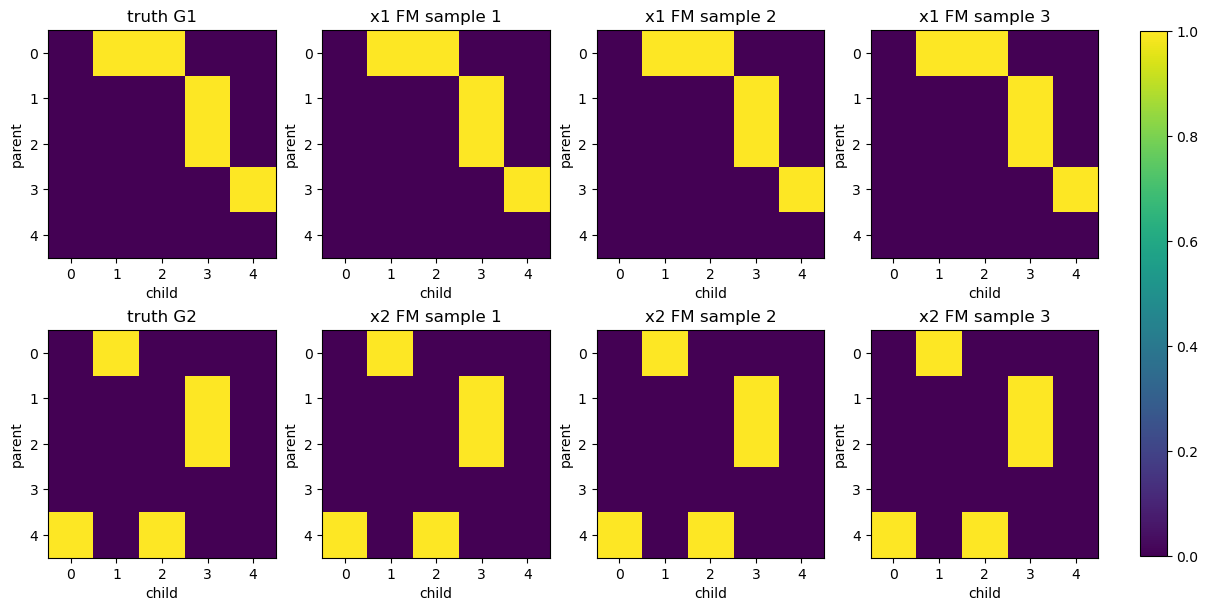

In [16]:
# =========================
# Result 3.2: ground truth + 3 generated graphs for x1/x2
# =========================

idx_x1 = int(np.where(z_test == 0)[0][0])
idx_x2 = int(np.where(z_test == 1)[0][0])

x1_std = X_test_std[idx_x1]
x2_std = X_test_std[idx_x2]

n_samples = settings["n_graph_samples_panel"]

samples_x1 = []
samples_x2 = []

for _ in range(n_samples):
    g, h = sample_one_posterior(
        fm,
        x1_std,
        target_edges=settings["target_edges"],
        n_h_steps=settings["gen_h_steps"],
        temp=settings["gen_temp"],
    )
    samples_x1.append(vec_to_graph(g.astype(int)))

for _ in range(n_samples):
    g, h = sample_one_posterior(
        fm,
        x2_std,
        target_edges=settings["target_edges"],
        n_h_steps=settings["gen_h_steps"],
        temp=settings["gen_temp"],
    )
    samples_x2.append(vec_to_graph(g.astype(int)))

# First column = ground truth, following columns = FM samples
graphs_row1 = [G_TRUE_1] + samples_x1
graphs_row2 = [G_TRUE_2] + samples_x2

titles_row1 = ["truth G1"] + [f"x1 FM sample {j+1}" for j in range(n_samples)]
titles_row2 = ["truth G2"] + [f"x2 FM sample {j+1}" for j in range(n_samples)]

ncols = n_samples + 1

fig, axes = plt.subplots(
    2,
    ncols,
    figsize=(3.0 * ncols, 6.0),
    constrained_layout=True,
)

for j in range(ncols):
    im = axes[0, j].imshow(graphs_row1[j], vmin=0, vmax=1, cmap="viridis")
    axes[0, j].set_title(titles_row1[j])
    axes[0, j].set_xlabel("child")
    axes[0, j].set_ylabel("parent")
    axes[0, j].set_xticks(range(D))
    axes[0, j].set_yticks(range(D))

    axes[1, j].imshow(graphs_row2[j], vmin=0, vmax=1, cmap="viridis")
    axes[1, j].set_title(titles_row2[j])
    axes[1, j].set_xlabel("child")
    axes[1, j].set_ylabel("parent")
    axes[1, j].set_xticks(range(D))
    axes[1, j].set_yticks(range(D))

fig.colorbar(
    im,
    ax=axes.ravel().tolist(),
    fraction=0.025,
    pad=0.04,
)

plt.show()

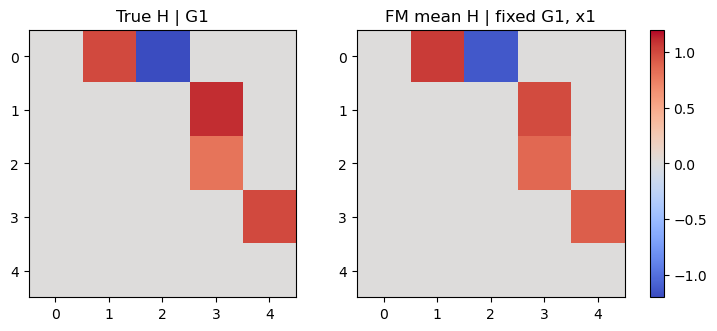

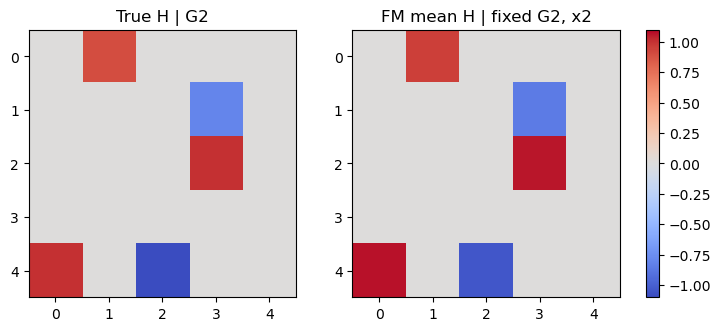

In [17]:

# =========================
# Result 3.3: parameters given the ground-truth graph
# =========================
g_true_1 = graph_to_vec(G_TRUE_1)
g_true_2 = graph_to_vec(G_TRUE_2)

Hs_g1 = sample_H_given_fixed_graph(
    fm, x1_std, g_true_1,
    n_samples=settings["n_param_samples"],
    n_h_steps=settings["gen_h_steps"]
)
Hs_g2 = sample_H_given_fixed_graph(
    fm, x2_std, g_true_2,
    n_samples=settings["n_param_samples"],
    n_h_steps=settings["gen_h_steps"]
)

H1_est = edgevec_to_matrix_np(Hs_g1.mean(axis=0))
H2_est = edgevec_to_matrix_np(Hs_g2.mean(axis=0))

vmax1 = max(np.abs(H_TRUE_1).max(), np.abs(H1_est).max(), 1e-6)
fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.2), constrained_layout=True)
im = axes[0].imshow(H_TRUE_1, cmap="coolwarm", vmin=-vmax1, vmax=vmax1)
axes[0].set_title("True H | G1")
axes[1].imshow(H1_est, cmap="coolwarm", vmin=-vmax1, vmax=vmax1)
axes[1].set_title("FM mean H | fixed G1, x1")
for ax in axes:
    ax.set_xticks(range(D))
    ax.set_yticks(range(D))
fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.03, pad=0.04)
plt.show()

vmax2 = max(np.abs(H_TRUE_2).max(), np.abs(H2_est).max(), 1e-6)
fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.2), constrained_layout=True)
im = axes[0].imshow(H_TRUE_2, cmap="coolwarm", vmin=-vmax2, vmax=vmax2)
axes[0].set_title("True H | G2")
axes[1].imshow(H2_est, cmap="coolwarm", vmin=-vmax2, vmax=vmax2)
axes[1].set_title("FM mean H | fixed G2, x2")
for ax in axes:
    ax.set_xticks(range(D))
    ax.set_yticks(range(D))
fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.03, pad=0.04)
plt.show()


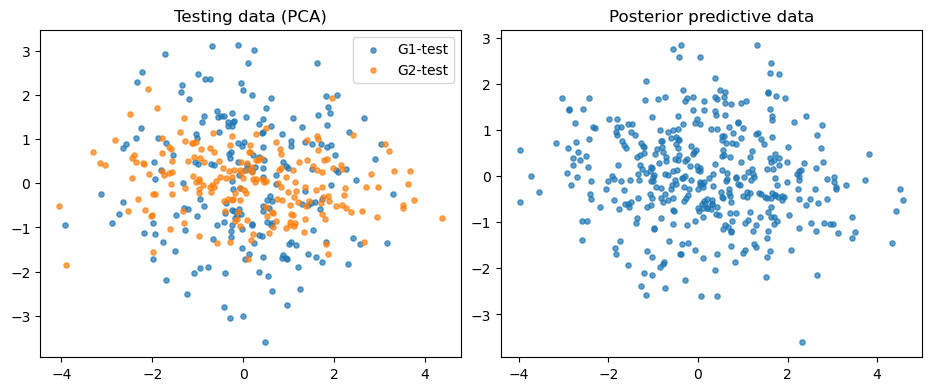

In [18]:

# =========================
# Result 3.4: generated vs testing data distribution
# =========================
X_gen = []
for g, h in zip(G_post, H_post):
    Gm = vec_to_graph(g.astype(int))
    Hm = edgevec_to_matrix_np(h)
    X_gen.append(simulate_sem_np(Gm, Hm, 1, settings["noise"])[0])
X_gen = np.stack(X_gen).astype(np.float32)
P_gen = pca.transform((X_gen - X_mean) / X_sd)

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.8), constrained_layout=True)
for lab, name in [(0, "G1-test"), (1, "G2-test")]:
    idx = z_test == lab
    axes[0].scatter(P_test[idx, 0], P_test[idx, 1], s=14, alpha=0.7, label=name)
axes[0].set_title("Testing data (PCA)")
axes[0].legend()

axes[1].scatter(P_gen[:, 0], P_gen[:, 1], s=14, alpha=0.7)
axes[1].set_title("Posterior predictive data")
plt.show()
